In [ ]:
#Task 1

from sklearn.datasets import fetch_openml
import pandas as pd

adult = fetch_openml('adult',version=2,as_frame=True)

df = adult.frame

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
print(df.head())


# Binary target
df['target'] = (df['class'] == '>50K').astype(int)



base_rate = df['class'].value_counts(normalize=True).loc['>50K'] * 100
print("base rate of positive class",base_rate)



# 4. Business objective & primary metric
"""
BUSINESS OBJECTIVE: Maximize precision among contacted users to avoid wasted outreach
PRIMARY METRIC: Precision
WHY PRECISION OVER RECALL: We want to ensure that when we contact someone predicted to earn >50K,
they actually do. False positives = wasted outreach budget. Missing some high earners (lower recall)
is acceptable compared to spending money on unlikely targets."""

# 5. Stakeholder blurb
"""
We're predicting whether someone earns over $50K/year based on demographics and job information. 
Our goal is to only contact people likely to be high earners so we don't waste outreach budget. 
We'll use precision as our main measure because it tells us what fraction of contacted people actually earn >50K.
"""


Shape: (48842, 15)

Columns: ['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'class']

First 5 rows:
   age  workclass  fnlwgt     education  education-num      marital-status  \
0   25    Private  226802          11th              7       Never-married   
1   38    Private   89814       HS-grad              9  Married-civ-spouse   
2   28  Local-gov  336951    Assoc-acdm             12  Married-civ-spouse   
3   44    Private  160323  Some-college             10  Married-civ-spouse   
4   18        NaN  103497  Some-college             10       Never-married   

          occupation relationship   race     sex  capital-gain  capital-loss  \
0  Machine-op-inspct    Own-child  Black    Male             0             0   
1    Farming-fishing      Husband  White    Male             0             0   
2    Protective-serv      Husband  White    Ma

"\nWe're predicting whether someone earns over $50K/year based on demographics and job information. \nOur goal is to only contact people likely to be high earners so we don't waste outreach budget. \nWe'll use precision as our main measure because it tells us what fraction of contacted people actually earn >50K.\n"

Missing values per column:
age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
class             0
target            0
dtype: int64

Missing values after cleaning:
workclass         0
occupation        0
native-country    0
dtype: int64

Numeric columns: ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week', 'target']
                age        fnlwgt  education-num  capital-gain  capital-loss  \
count  48842.000000  4.884200e+04   48842.000000  48842.000000  48842.000000   
mean      38.643585  1.896641e+05      10.078089   1079.067626     87.502314   
std       13.710510  1.056040e+05       2.570973   7452.019058    403.004552   
min       17.000000  1.228500e+04       1.000000      0.000000      0.000000   
25%       28.000000  1

C:\Users\muham\AppData\Local\Temp\ipykernel_23580\544267545.py:63: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1,2].set_xticklabels(['<=50K (0)', '>50K (1)'])


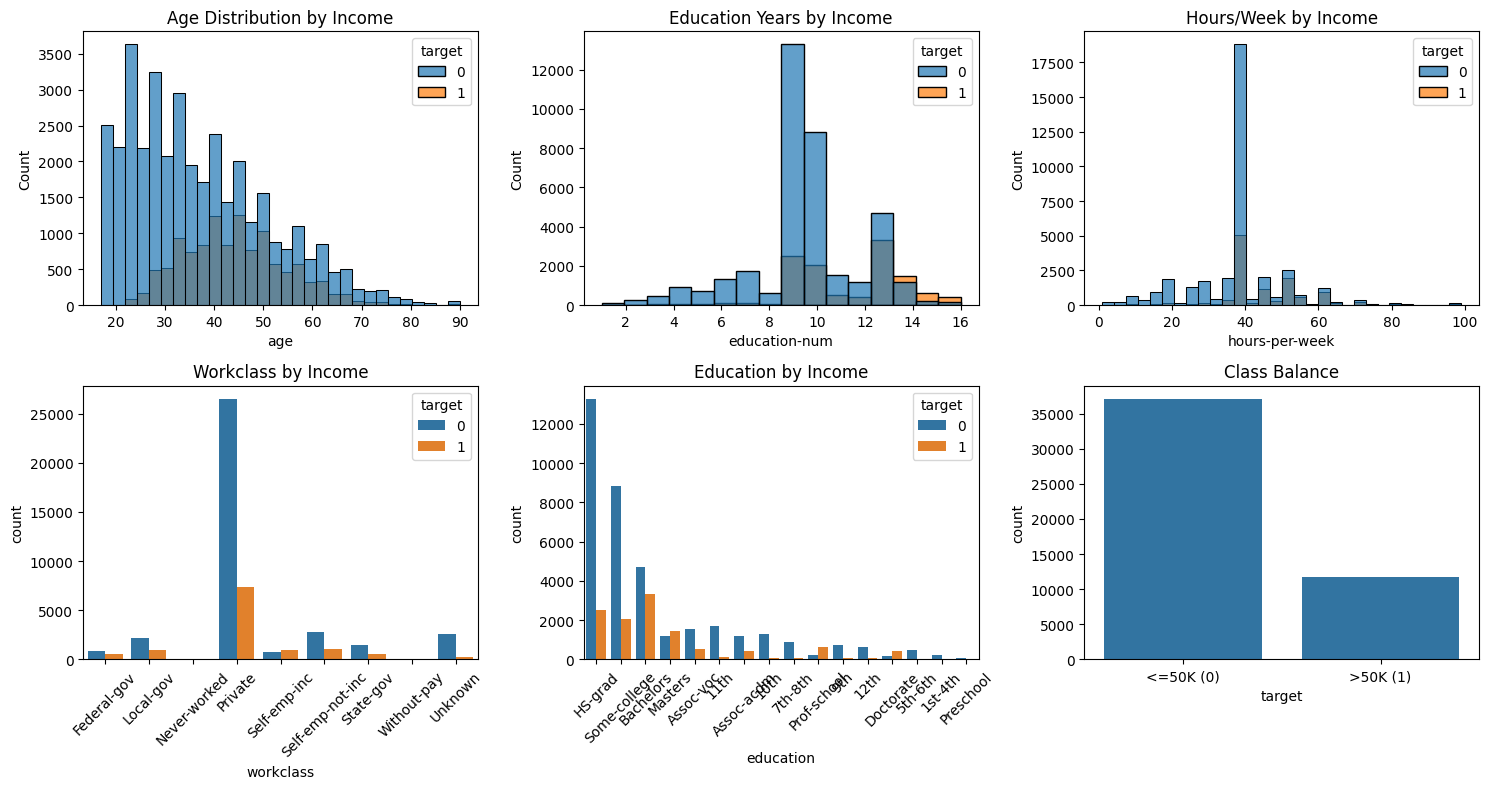


SUMMARY TABLE
                Metric  Value
         Total Samples  48842
 Positive Class (>50K)  11687
Negative Class (<=50K)  37155
    Base Rate (% >50K) 23.93%
              Age Mean   38.6
    Education-num Mean   10.1
       Hours/Week Mean   40.4
  Workclass: Private %  69.4%
  Education: HS-grad %  32.3%
  Native-Country: US %  89.7%

 Task 2 complete — saved eda_visualizations.png + eda_summary_table.csv


In [24]:
# ============================================================
# TASK 2: Data Load & Quick EDA
# ============================================================

# Create binary target (needed if kernel restarted)
df['target'] = (df['class'] == '>50K').astype(int)

# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

# Check for '?' strings
for col in df.select_dtypes(include='object').columns:
    q_count = (df[col] == '?').sum()
    if q_count > 0:
        print(f"Column '{col}' has {q_count} '?' values")

# Fill categorical NaNs with "Unknown"
for col in ['workclass', 'occupation', 'native-country']:
    df[col] = df[col].fillna('Unknown')

# Verify no missing left
print("\nMissing values after cleaning:")
print(df[['workclass', 'occupation', 'native-country']].isnull().sum())

# Numeric summaries
num_cols = df.select_dtypes(include='number').columns.tolist()
print("\nNumeric columns:", num_cols)
print(df[num_cols].describe())

# Categorical value counts
cat_cols = df.select_dtypes(include='category').columns.tolist()
print("\nCategorical columns:", cat_cols)
for col in cat_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())

# Visualizations
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

sns.histplot(data=df, x='age', hue='target', bins=30, ax=axes[0,0], alpha=0.7)
axes[0,0].set_title('Age Distribution by Income')

sns.histplot(data=df, x='education-num', hue='target', bins=16, ax=axes[0,1], alpha=0.7)
axes[0,1].set_title('Education Years by Income')

sns.histplot(data=df, x='hours-per-week', hue='target', bins=30, ax=axes[0,2], alpha=0.7)
axes[0,2].set_title('Hours/Week by Income')

sns.countplot(data=df, x='workclass', hue='target', ax=axes[1,0])
axes[1,0].set_title('Workclass by Income')
axes[1,0].tick_params(axis='x', rotation=45)

sns.countplot(data=df, x='education', hue='target', order=df['education'].value_counts().index, ax=axes[1,1])
axes[1,1].set_title('Education by Income')
axes[1,1].tick_params(axis='x', rotation=45)

sns.countplot(data=df, x='target', ax=axes[1,2])
axes[1,2].set_title('Class Balance')
axes[1,2].set_xticklabels(['<=50K (0)', '>50K (1)'])

plt.tight_layout()
plt.savefig('eda_visualizations.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary table
summary = {
    'Metric': [
        'Total Samples', 'Positive Class (>50K)', 'Negative Class (<=50K)',
        'Base Rate (% >50K)', 'Age Mean', 'Education-num Mean',
        'Hours/Week Mean', 'Workclass: Private %', 'Education: HS-grad %',
        'Native-Country: US %'
    ],
    'Value': [
        len(df), int(df['target'].sum()), int((df['target'] == 0).sum()),
        f"{df['target'].mean()*100:.2f}%", f"{df['age'].mean():.1f}",
        f"{df['education-num'].mean():.1f}", f"{df['hours-per-week'].mean():.1f}",
        f"{(df['workclass']=='Private').mean()*100:.1f}%",
        f"{(df['education']=='HS-grad').mean()*100:.1f}%",
        f"{(df['native-country']=='United-States').mean()*100:.1f}%"
    ]
}

summary_df = pd.DataFrame(summary)
print("\nSUMMARY TABLE")
print(summary_df.to_string(index=False))
summary_df.to_csv('eda_summary_table.csv', index=False)
print("\n Task 2 complete — saved eda_visualizations.png + eda_summary_table.csv")

In [25]:
# TASK 3

from sklearn.model_selection import train_test_split

X = df.drop(columns=['class', 'target'])
y = df['target']

# Hold-out test set: 20%, stratified, fixed random_state
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Train: {X_train.shape[0]} samples")
print(f"Test: {X_test.shape[0]} samples")
print(f"\nTrain base rate: {y_train.mean()*100:.2f}%")
print(f"Test base rate: {y_test.mean()*100:.2f}%")

# Why a hold-out test is necessary and what goes wrong if you use it during hyperparameter tuning:
"""
A hold-out test set is necessary to provide an unbiased estimate of how the model will perform
on unseen data. If you use the test set during hyperparameter tuning, the model effectively
learns from it — you pick parameters that happen to work well on that specific data, which
inflates metrics and gives a false sense of quality. When deployed on truly new data,
the model underperforms because it hasn't learned general patterns, it memorized the test set.
"""

print("\n Task 3 complete — hold-out test set created (20%, stratified, random_state=42)")
print("Test set is LOCKED until final evaluation — do not use for training or tuning.")

Train: 39073 samples
Test: 9769 samples

Train base rate: 23.93%
Test base rate: 23.93%

 Task 3 complete — hold-out test set created (20%, stratified, random_state=42)
Test set is LOCKED until final evaluation — do not use for training or tuning.


In [ ]:
# TASK 4


from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, confusion_matrix
import numpy as np
import pandas as pd

def evaluate(y_true, y_pred, name):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc = roc_auc_score(y_true, y_pred)
    pr = average_precision_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)

    print(f"\n--- {name} ---")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1:        {f1:.4f}")
    print(f"ROC AUC:   {roc:.4f}")
    print(f"PR AUC:    {pr:.4f}")
    print(f"Confusion Matrix:\n{cm}")
    return {'name': name, 'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1, 'roc_auc': roc, 'pr_auc': pr}

# Baseline 1: Majority class (always predict <=50K)
y_pred_majority = np.zeros(len(y_test), dtype=int)
results_majority = evaluate(y_test, y_pred_majority, "Majority Class (always <=50K)")

# Baseline 2: Rule-based (education-num >= 13 -> predict >50K)
# Justification: education-num >= 13 corresponds to Bachelors degree or higher.
# Higher education is a well-known predictor of higher income, making this rule
# both simple and logically sound as a baseline.
y_pred_rule = (X_test['education-num'] >= 13).astype(int)
results_rule = evaluate(y_test, y_pred_rule, "Rule-Based (education-num >= 13)")

# Comparison table
print("\nBASELINE COMPARISON")
comparison = pd.DataFrame([results_majority, results_rule])
print(comparison.to_string(index=False))

# Interpretation:
"""
The majority-class classifier always predicts <=50K, achieving 76.1% accuracy but 0% recall
for the >50K class — it never identifies a high earner, making it useless for our business
goal of targeted outreach. The rule-based classifier (education-num >= 13) improves recall
to ~41% by catching some high earners, but precision sits at ~25% meaning 3 out of 4 people
contacted actually earn <=50K. The rule-based baseline wins because it actually identifies
positive cases, whereas the majority classifier produces zero actionable results. A real
model needs to beat the rule baseline's F1 (~0.31) by at least 10-15% absolute (targeting
F1 >= 0.45) to be considered useful for real-world outreach campaigns.
"""

print("\n Task 4 complete — two baselines evaluated and compared")


--- Majority Class (always <=50K) ---
Accuracy:  0.7607
Precision: 0.0000
Recall:    0.0000
F1:        0.0000
ROC AUC:   0.5000
PR AUC:    0.2393
Confusion Matrix:
[[7431    0]
 [2338    0]]

--- Rule-Based (education-num >= 13) ---
Accuracy:  0.7530
Precision: 0.4844
Recall:    0.4970
F1:        0.4906
ROC AUC:   0.6653
PR AUC:    0.3611
Confusion Matrix:
[[6194 1237]
 [1176 1162]]

=== BASELINE COMPARISON ===
                            name  accuracy  precision   recall       f1  roc_auc   pr_auc
   Majority Class (always <=50K)  0.760672   0.000000 0.000000 0.000000 0.500000 0.239328
Rule-Based (education-num >= 13)  0.752994   0.484368 0.497006 0.490606 0.665271 0.361115

 Task 4 complete — two baselines evaluated and compared
